# Mathematics TopK SAE Retraining and Carry Specificity

This is a targeted follow-up, not a replacement for the completed final experiments. It tests whether explicitly sparse TopK SAEs concentrate the small graph-held-out carry effect found with the original dense ReLU SAEs.

The candidate is selected using reconstruction and sparsity diagnostics only. Intervention outcomes are not used for selection. Existing activations are recaptured deterministically, while all checkpoints, graphs, intervention JSONs and figures use distinct TopK names.

Expected runtime is dominated by one attribution graph, previously about 30 minutes. Training all candidates and running the held-out benchmark should be much shorter.

## 1. Mount Drive and fetch the current repository

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import subprocess

repo_url = 'https://github.com/evey-dev/test_run.git'
repo_dir = '/content/test_run'

def run_cmd(command):
    print('$', ' '.join(map(str, command)))
    subprocess.run(command, check=True)

github_ok = False
try:
    checkout = repo_dir
    if os.path.isdir(os.path.join(checkout, '.git')):
        run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
    else:
        if os.path.exists(checkout) and os.listdir(checkout):
            checkout = '/content/test_run_github'
        if os.path.isdir(os.path.join(checkout, '.git')):
            run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
        elif os.path.exists(checkout) and os.listdir(checkout):
            raise RuntimeError(f'{checkout} exists but is not a git repository')
        else:
            run_cmd(['git', 'clone', '--depth', '1', repo_url, checkout])
    os.chdir(checkout)
    github_ok = True
    print('Using GitHub checkout:', os.getcwd())
except Exception as exc:
    print('GitHub checkout failed; using Drive project.zip backup.')
    print(repr(exc))

if not github_ok:
    zip_path = '/content/drive/MyDrive/mphil-project/project.zip'
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'Could not find {zip_path}')
    run_cmd(['unzip', '-q', '-o', zip_path, '-d', '/content/'])
    for candidate in ['/content/test_run', '/content/mphil_project/test_run', '/content']:
        if os.path.isdir(os.path.join(candidate, 'src')) and os.path.isdir(os.path.join(candidate, 'configs')):
            os.chdir(candidate)
            break
    else:
        raise FileNotFoundError('Could not locate the extracted repository root')

print('Current working directory:', os.getcwd())

Mounted at /content/drive
$ git clone --depth 1 https://github.com/evey-dev/test_run.git /content/test_run
Using GitHub checkout: /content/test_run
Current working directory: /content/test_run


## 2. Install dependencies and regenerate the deterministic datasets

In [2]:
!pip install -q --upgrade "transformers>=4.51.0" accelerate matplotlib
!pip install -q -e .
!python data/generate_datasets.py --capitals

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 149.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 161.8 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
Generating Datasets...

Flag '--capitals' captured. Building structural sentences for geography data...
Saved 1000 capital entries with text templates.
Standalone Mode complete:
Saved 1000 addition problems and 
Saved 1000 unit problems.


## 3. Fixed candidates and output locations

The only candidate-dependent hyperparameter is TopK width. All candidates use the same seven layers, activation corpus, 80:20 split, seed, latent dimension, optimiser and epoch count. Decoder columns are constrained to unit norm and the L1 penalty is disabled because TopK directly enforces sparsity.

In [3]:
from pathlib import Path
import json
import shutil
import sys

LAYERS = [4, 8, 12, 16, 20, 24, 28]
CANDIDATES = {
    128: 'configs/sae_math_topk128_config.yaml',
    256: 'configs/sae_math_topk256_config.yaml',
    512: 'configs/sae_math_topk512_config.yaml',
}
DRIVE_ROOT = Path('/content/drive/MyDrive/mphil-project')
DRIVE_CHECKPOINT_ROOT = DRIVE_ROOT / 'mechanistic_data' / 'topk_math_retrain'
DRIVE_OUTPUT = DRIVE_ROOT / 'outputs' / 'topk_math_retrain'
LOCAL_OUTPUT = Path('outputs/topk_math_retrain')
FIGURE_OUTPUT = LOCAL_OUTPUT / 'figures'
for path in (DRIVE_CHECKPOINT_ROOT, DRIVE_OUTPUT, LOCAL_OUTPUT, FIGURE_OUTPUT):
    path.mkdir(parents=True, exist_ok=True)

print('Candidates:', CANDIDATES)
print('Drive checkpoint root:', DRIVE_CHECKPOINT_ROOT)
print('Drive output root:', DRIVE_OUTPUT)

Candidates: {128: 'configs/sae_math_topk128_config.yaml', 256: 'configs/sae_math_topk256_config.yaml', 512: 'configs/sae_math_topk512_config.yaml'}
Drive checkpoint root: /content/drive/MyDrive/mphil-project/mechanistic_data/topk_math_retrain
Drive output root: /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain


## 4. Recapture the original mathematics activation corpus

This deliberately uses the same final-position training support as the original mathematics SAEs. The follow-up isolates sparsity and decoder normalisation rather than changing several design variables simultaneously.

In [4]:
activation_dir = Path('mechanistic_data_math_topk_retrain')
activation_complete = (activation_dir / 'train_val_indices_per_layer.npy').exists() and all(
    (activation_dir / f'activations_layer{layer}.npy').exists() for layer in LAYERS
)
if activation_complete:
    print('Reusing complete local TopK mathematics activation bundle.')
else:
    run_cmd([
        sys.executable, '-m', 'src.capture_activations',
        '--output-dir', str(activation_dir),
        '--behaviours', 'addition',
        '--layers', *map(str, LAYERS),
        '--seed', '787',
    ])

$ /usr/bin/python3 -m src.capture_activations --output-dir mechanistic_data_math_topk_retrain --behaviours addition --layers 4 8 12 16 20 24 28 --seed 787


## 5. Train or restore all three TopK candidates

In [5]:
for top_k, config in CANDIDATES.items():
    drive_dir = DRIVE_CHECKPOINT_ROOT / f'k{top_k}'
    drive_dir.mkdir(parents=True, exist_ok=True)
    print(f'\n=== Training/restoring TopK {top_k} ===')
    run_cmd([
        sys.executable, '-m', 'src.train',
        '--config', config,
        '--drive-dir', str(drive_dir),
    ])


=== Training/restoring TopK 128 ===
$ /usr/bin/python3 -m src.train --config configs/sae_math_topk128_config.yaml --drive-dir /content/drive/MyDrive/mphil-project/mechanistic_data/topk_math_retrain/k128

=== Training/restoring TopK 256 ===
$ /usr/bin/python3 -m src.train --config configs/sae_math_topk256_config.yaml --drive-dir /content/drive/MyDrive/mphil-project/mechanistic_data/topk_math_retrain/k256

=== Training/restoring TopK 512 ===
$ /usr/bin/python3 -m src.train --config configs/sae_math_topk512_config.yaml --drive-dir /content/drive/MyDrive/mphil-project/mechanistic_data/topk_math_retrain/k512


## 6. Evaluate candidates before any intervention

Selection requires mean validation FVE at least 0.90, every selected layer's validation FVE at least 0.85, and mean dead-feature fraction at most 0.80. Among candidates meeting all thresholds, the smallest mean validation L0 is selected.

In [6]:
diagnostic_csvs = []
for top_k, config in CANDIDATES.items():
    json_path = LOCAL_OUTPUT / f'math_topk{top_k}_diagnostics.json'
    csv_path = LOCAL_OUTPUT / f'math_topk{top_k}_diagnostics.csv'
    diagnostic_csvs.append(csv_path)
    run_cmd([
        sys.executable, '-m', 'src.sae_diagnostics',
        '--config', config,
        '--label', f'math_topk{top_k}',
        '--output-json', str(json_path),
        '--output-csv', str(csv_path),
        '--device', 'auto',
    ])

selection_path = LOCAL_OUTPUT / 'math_topk_selection.json'
run_cmd([
    sys.executable, '-m', 'src.select_sae_candidate',
    '--configs', *CANDIDATES.values(),
    '--diagnostics', *map(str, diagnostic_csvs),
    '--minimum-mean-fve', '0.90',
    '--minimum-layer-fve', '0.85',
    '--maximum-mean-dead-fraction', '0.80',
    '--output', str(selection_path),
])

selection = json.loads(selection_path.read_text())
for source in [*LOCAL_OUTPUT.glob('math_topk*_diagnostics.*'), selection_path]:
    destination = DRIVE_OUTPUT / source.name
    shutil.copy2(source, destination)
    print('Backed up pre-intervention evidence:', destination)
selected = selection.get('selected')
if selected is None:
    raise RuntimeError(
        'No candidate met the predeclared reconstruction thresholds. '
        'Stop here rather than spending time on a graph. The diagnostics are still a valid negative result.'
    )
SELECTED_CONFIG = selected['config']
SELECTED_K = int(selected['top_k'])
print(f'Proceeding with preselected candidate: TopK {SELECTED_K} ({SELECTED_CONFIG})')

$ /usr/bin/python3 -m src.sae_diagnostics --config configs/sae_math_topk128_config.yaml --label math_topk128 --output-json outputs/topk_math_retrain/math_topk128_diagnostics.json --output-csv outputs/topk_math_retrain/math_topk128_diagnostics.csv --device auto
$ /usr/bin/python3 -m src.sae_diagnostics --config configs/sae_math_topk256_config.yaml --label math_topk256 --output-json outputs/topk_math_retrain/math_topk256_diagnostics.json --output-csv outputs/topk_math_retrain/math_topk256_diagnostics.csv --device auto
$ /usr/bin/python3 -m src.sae_diagnostics --config configs/sae_math_topk512_config.yaml --label math_topk512 --output-json outputs/topk_math_retrain/math_topk512_diagnostics.json --output-csv outputs/topk_math_retrain/math_topk512_diagnostics.csv --device auto
$ /usr/bin/python3 -m src.select_sae_candidate --configs configs/sae_math_topk128_config.yaml configs/sae_math_topk256_config.yaml configs/sae_math_topk512_config.yaml --diagnostics outputs/topk_math_retrain/math_topk

In [7]:
import pandas as pd
from IPython.display import display

comparison_rows = []
for candidate in selection['candidates']:
    comparison_rows.append({
        'k': candidate['top_k'],
        'mean validation FVE': candidate['mean_validation_fve'],
        'minimum layer FVE': candidate['minimum_layer_validation_fve'],
        'mean validation L0': candidate['mean_validation_l0'],
        'dead-feature fraction': candidate['mean_dead_feature_fraction'],
        'selected': candidate['config'] == SELECTED_CONFIG,
    })
display(pd.DataFrame(comparison_rows).round(4))

,k,mean validation FVE,minimum layer FVE,mean validation L0,dead-feature fraction,selected
0,128,0.9466,0.9394,124.5650,0.8324,False
1,256,0.9410,0.9319,171.6029,0.7162,True
2,512,0.9352,0.9249,217.9221,0.6018,False


## 7. Restore optional original reference outputs

These files are used only for after-the-fact comparison and plotting. They do not affect candidate selection.

In [8]:
reference_names = [
    'final_sae_diagnostics_math.csv',
    'final_heldout_validation.json',
]
for name in reference_names:
    local = Path('outputs') / name
    drive_source = DRIVE_ROOT / 'outputs' / name
    if not local.exists() and drive_source.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(drive_source, local)
        print('Restored reference:', name)
    elif local.exists():
        print('Reference ready:', local)
    else:
        print('Optional reference unavailable:', drive_source)

Restored reference: final_sae_diagnostics_math.csv
Reference ready: outputs/final_heldout_validation.json


## 8. Build or restore exactly one selected TopK attribution graph

In [9]:
GRAPH_STEM = f'math_topk{SELECTED_K}_carry_58_83_4v3_graph'
graph_paths = {
    suffix: LOCAL_OUTPUT / f'{GRAPH_STEM}.{suffix}'
    for suffix in ('json', 'html', 'md')
}
drive_graph_paths = {
    suffix: DRIVE_OUTPUT / f'{GRAPH_STEM}.{suffix}'
    for suffix in graph_paths
}
if all(path.exists() for path in drive_graph_paths.values()):
    for suffix in graph_paths:
        shutil.copy2(drive_graph_paths[suffix], graph_paths[suffix])
    print('Restored selected graph from Drive:', GRAPH_STEM)
else:
    run_cmd([
        sys.executable, '-m', 'src.attribution_graph',
        '--prompt', 'Question: What is 58 + 83? Answer: 1',
        '--target', '4',
        '--contrast-target', '3',
        '--layers', *map(str, LAYERS),
        '--sae-config', SELECTED_CONFIG,
        '--output-json', str(graph_paths['json']),
        '--output-html', str(graph_paths['html']),
        '--output-mermaid', str(graph_paths['md']),
    ])
    for suffix in graph_paths:
        shutil.copy2(graph_paths[suffix], drive_graph_paths[suffix])
        print('Copied graph to Drive:', drive_graph_paths[suffix])

$ /usr/bin/python3 -m src.attribution_graph --prompt Question: What is 58 + 83? Answer: 1 --target 4 --contrast-target 3 --layers 4 8 12 16 20 24 28 --sae-config configs/sae_math_topk256_config.yaml --output-json outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.json --output-html outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.html --output-mermaid outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.md
Copied graph to Drive: /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.json
Copied graph to Drive: /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.html
Copied graph to Drive: /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.md


## 9. Run the unchanged graph-held-out benchmark and matched no-carry control

The same deterministic 12 graph-held-out carry pairs are used. In addition, the selected positive graph features are inhibited on each matched no-carry source. Candidate selection is already complete and cannot depend on these outcomes.

In [10]:
heldout_path = LOCAL_OUTPUT / f'math_topk{SELECTED_K}_heldout_specificity.json'
run_cmd([
    sys.executable, '-m', 'src.heldout_validation',
    '--math-sae-config', SELECTED_CONFIG,
    '--math-graph', str(graph_paths['json']),
    '--math-cases', '12',
    '--skip-units',
    '--math-specificity-control',
    '--output', str(heldout_path),
])

topk_result = json.loads(heldout_path.read_text())
print('\nSelected TopK intervention summary:')
display(pd.DataFrame(topk_result['math']['summary']['conditions']).T.round(4))
print('\nMatched specificity summary:')
display(pd.Series(topk_result['math']['specificity_summary']).to_frame('value'))

$ /usr/bin/python3 -m src.heldout_validation --math-sae-config configs/sae_math_topk256_config.yaml --math-graph outputs/topk_math_retrain/math_topk256_carry_58_83_4v3_graph.json --math-cases 12 --skip-units --math-specificity-control --output outputs/topk_math_retrain/math_topk256_heldout_specificity.json

Selected TopK intervention summary:


,mean_gap_delta,median_gap_delta,bootstrap_95_ci_mean,fraction_in_predicted_direction,top_prediction_transfer_fraction
full_latent_swap,-0.5625,-0.5,"[-0.9270833333333334, -0.2708333333333333]",0.75,0.0
raw_mlp_swap,-13.989583,-14.375,"[-14.989583333333334, -12.854166666666666]",1.0,1.0
sparse_inhibition,-0.875,-0.9375,"[-0.96875, -0.7708333333333334]",1.0,0.0



Matched specificity summary:


,value
eligible_cases,12
target_definition,carry-target correct-minus-dropped-carry gap d...
control_definition,matched no-carry correct-minus-carry-injected ...
paired_difference_definition,target delta minus matched no-carry control de...
mean_target_delta,-0.875
bootstrap_95_ci_mean_target_delta,"[-0.96875, -0.7708333333333334]"
mean_no_carry_control_delta,-0.885417
bootstrap_95_ci_mean_no_carry_control_delta,"[-0.9583333333333334, -0.8229166666666666]"
mean_paired_difference,0.010417
bootstrap_95_ci_mean_paired_difference,"[-0.125, 0.16666666666666666]"


In [11]:
original_heldout_path = Path('outputs/final_heldout_validation.json')
if original_heldout_path.exists():
    original = json.loads(original_heldout_path.read_text())
    rows = []
    for condition in ('sparse_inhibition', 'full_latent_swap', 'raw_mlp_swap'):
        rows.append({
            'condition': condition,
            'original mean delta': original['math']['summary']['conditions'][condition]['mean_gap_delta'],
            'TopK mean delta': topk_result['math']['summary']['conditions'][condition]['mean_gap_delta'],
        })
    print('Original versus selected TopK benchmark:')
    display(pd.DataFrame(rows).set_index('condition').round(4))
else:
    print('Original held-out JSON unavailable; TopK result is still complete.')

Original versus selected TopK benchmark:


,original mean delta,TopK mean delta
condition,,
sparse_inhibition,-0.3958,-0.8750
full_latent_swap,-0.3854,-0.5625
raw_mlp_swap,-13.9896,-13.9896


## 10. Generate the comparison figure and persist all outputs

$ /usr/bin/python3 -m src.plot_topk_math --candidate-diagnostics outputs/topk_math_retrain/math_topk128_diagnostics.csv outputs/topk_math_retrain/math_topk256_diagnostics.csv outputs/topk_math_retrain/math_topk512_diagnostics.csv --selection outputs/topk_math_retrain/math_topk_selection.json --new-heldout outputs/topk_math_retrain/math_topk256_heldout_specificity.json --output-dir outputs/topk_math_retrain/figures --original-diagnostics outputs/final_sae_diagnostics_math.csv --original-heldout outputs/final_heldout_validation.json


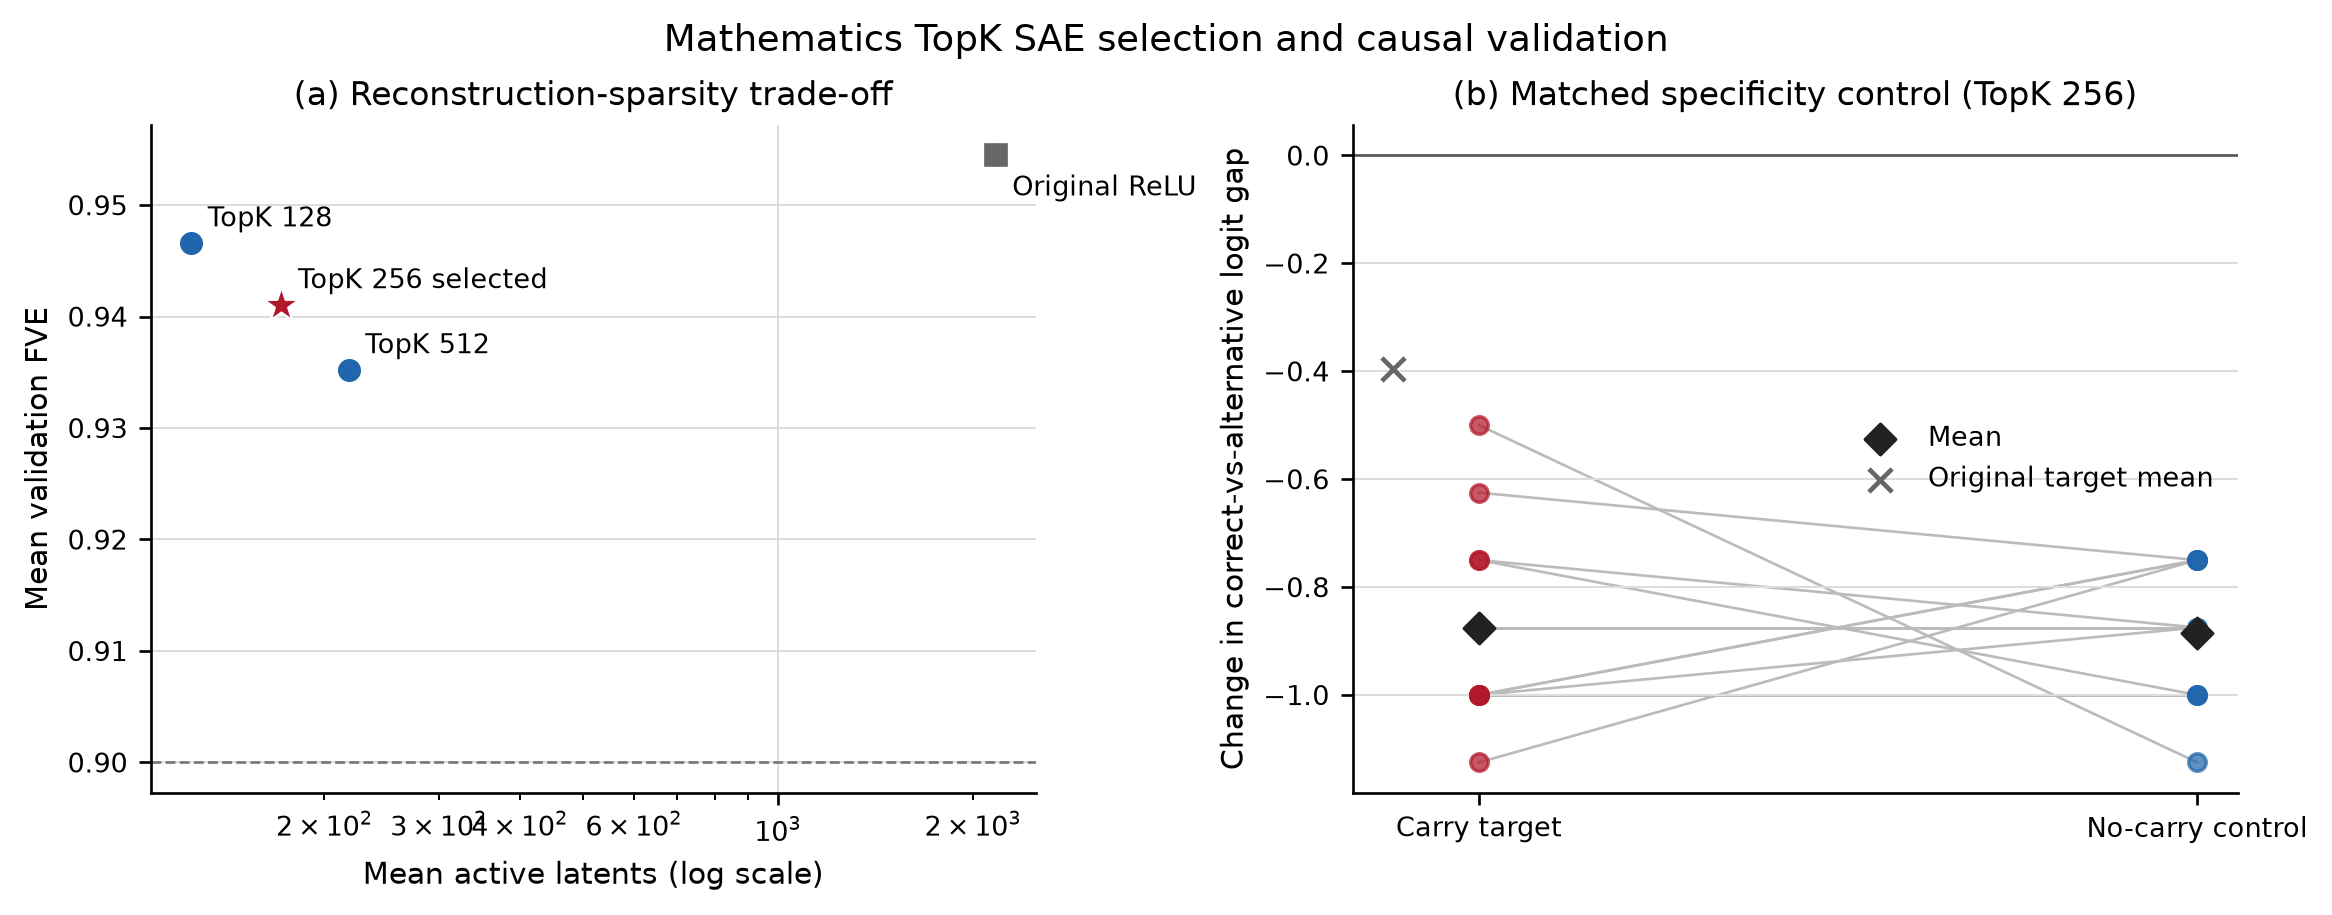

In [12]:
plot_command = [
    sys.executable, '-m', 'src.plot_topk_math',
    '--candidate-diagnostics', *map(str, diagnostic_csvs),
    '--selection', str(selection_path),
    '--new-heldout', str(heldout_path),
    '--output-dir', str(FIGURE_OUTPUT),
]
original_diagnostics = Path('outputs/final_sae_diagnostics_math.csv')
if original_diagnostics.exists():
    plot_command.extend(['--original-diagnostics', str(original_diagnostics)])
if original_heldout_path.exists():
    plot_command.extend(['--original-heldout', str(original_heldout_path)])
run_cmd(plot_command)

from IPython.display import Image
display(Image(filename=str(FIGURE_OUTPUT / 'fig_math_topk_tradeoff_specificity.png')))

In [13]:
for source in LOCAL_OUTPUT.rglob('*'):
    if not source.is_file():
        continue
    relative = source.relative_to(LOCAL_OUTPUT)
    destination = DRIVE_OUTPUT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    print('Copied', relative)

print('\nTopK follow-up complete.')
print('Selected k:', SELECTED_K)
print('Local outputs:', LOCAL_OUTPUT)
print('Drive outputs:', DRIVE_OUTPUT)

Copied math_topk256_carry_58_83_4v3_graph.md
Copied math_topk256_diagnostics.json
Copied math_topk128_diagnostics.csv
Copied math_topk128_diagnostics.json
Copied math_topk512_diagnostics.csv
Copied math_topk_selection.json
Copied math_topk512_diagnostics.json
Copied math_topk256_carry_58_83_4v3_graph.json
Copied math_topk256_carry_58_83_4v3_graph.html
Copied math_topk256_heldout_specificity.json
Copied math_topk256_diagnostics.csv
Copied figures/fig_math_topk_tradeoff_specificity.pdf
Copied figures/fig_math_topk_tradeoff_specificity.png

TopK follow-up complete.
Selected k: 256
Local outputs: outputs/topk_math_retrain
Drive outputs: /content/drive/MyDrive/mphil-project/outputs/topk_math_retrain
